# Multiple Linear Regression

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



## Importing the dataset

In [9]:
dataset = pd.read_csv("50_Startups.csv")
x = dataset.iloc [ : , :-1].values #Matrix of features
y = dataset.iloc [ : , -1].values #Dependent variable vector

In [10]:
#Before OneHotEncoder:
x

array([[165349.2, 136897.8, 471784.1, 'New York'],
       [162597.7, 151377.59, 443898.53, 'California'],
       [153441.51, 101145.55, 407934.54, 'Florida'],
       [144372.41, 118671.85, 383199.62, 'New York'],
       [142107.34, 91391.77, 366168.42, 'Florida'],
       [131876.9, 99814.71, 362861.36, 'New York'],
       [134615.46, 147198.87, 127716.82, 'California'],
       [130298.13, 145530.06, 323876.68, 'Florida'],
       [120542.52, 148718.95, 311613.29, 'New York'],
       [123334.88, 108679.17, 304981.62, 'California'],
       [101913.08, 110594.11, 229160.95, 'Florida'],
       [100671.96, 91790.61, 249744.55, 'California'],
       [93863.75, 127320.38, 249839.44, 'Florida'],
       [91992.39, 135495.07, 252664.93, 'California'],
       [119943.24, 156547.42, 256512.92, 'Florida'],
       [114523.61, 122616.84, 261776.23, 'New York'],
       [78013.11, 121597.55, 264346.06, 'California'],
       [94657.16, 145077.58, 282574.31, 'New York'],
       [91749.16, 114175.79, 29491

## Encoding categorical data

In [11]:
#Notice that we have a categorical column in the dataset. We need to encode it before we can use it in the model.
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#Let's encode the categorical column

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [12]:
#After OneHotEncoder:
x

#New york was encoded as 0 0 1 
#While California was encoded as 1 0 0 
#And Florida was encoded as 0 1 0

array([[0.0, 0.0, 1.0, 165349.2, 136897.8, 471784.1],
       [1.0, 0.0, 0.0, 162597.7, 151377.59, 443898.53],
       [0.0, 1.0, 0.0, 153441.51, 101145.55, 407934.54],
       [0.0, 0.0, 1.0, 144372.41, 118671.85, 383199.62],
       [0.0, 1.0, 0.0, 142107.34, 91391.77, 366168.42],
       [0.0, 0.0, 1.0, 131876.9, 99814.71, 362861.36],
       [1.0, 0.0, 0.0, 134615.46, 147198.87, 127716.82],
       [0.0, 1.0, 0.0, 130298.13, 145530.06, 323876.68],
       [0.0, 0.0, 1.0, 120542.52, 148718.95, 311613.29],
       [1.0, 0.0, 0.0, 123334.88, 108679.17, 304981.62],
       [0.0, 1.0, 0.0, 101913.08, 110594.11, 229160.95],
       [1.0, 0.0, 0.0, 100671.96, 91790.61, 249744.55],
       [0.0, 1.0, 0.0, 93863.75, 127320.38, 249839.44],
       [1.0, 0.0, 0.0, 91992.39, 135495.07, 252664.93],
       [0.0, 1.0, 0.0, 119943.24, 156547.42, 256512.92],
       [0.0, 0.0, 1.0, 114523.61, 122616.84, 261776.23],
       [1.0, 0.0, 0.0, 78013.11, 121597.55, 264346.06],
       [0.0, 0.0, 1.0, 94657.16, 145077.58

## Splitting the dataset into the Training set and Test set

In [15]:
#This class wil automatically avoid the dummy variable trap so we dont need to worry about it.
#We also don't need to worry about using backward elimination to find the feautures that are statistically significant because the library will do that for us.

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)



## Training the Multiple Linear Regression model on the Training set

In [18]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 86.64,-872.65, 786.01, 0.77, 0.03, 0.04]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.247e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[810968.73,214655.43,134523.37, 3.8 , 3.23, 0. ]"


## Predicting the Test set results

In [21]:
#To visualize the date here we can't use a plot because we have 4 features, we will use 2 vectors instead. One with the real values and one with the predicted values.

y_pred = regressor.predict(x_test) #The vector with the predicted values
np.set_printoptions (precision = 2) #We can set the precision of the printed values to be able to see the values more clearly
print(np.concatenate ((y_pred.reshape (len(y_pred), 1) , y_test.reshape (len(y_test), 1)), 1))

[[103015.2  103282.38]
 [132582.28 144259.4 ]
 [132447.74 146121.95]
 [ 71976.1   77798.83]
 [178537.48 191050.39]
 [116161.24 105008.31]
 [ 67851.69  81229.06]
 [ 98791.73  97483.56]
 [113969.44 110352.25]
 [167921.07 166187.94]]


Visualizing the data in an even better way

In [22]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison)

      Actual      Predicted
0  103282.38  103015.201598
1  144259.40  132582.277608
2  146121.95  132447.738452
3   77798.83   71976.098513
4  191050.39  178537.482211
5  105008.31  116161.242302
6   81229.06   67851.692097
7   97483.56   98791.733747
8  110352.25  113969.435330
9  166187.94  167921.065696


In [23]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison["Error"] = comparison["Predicted"] - comparison["Actual"]

print(comparison)

      Actual      Predicted         Error
0  103282.38  103015.201598   -267.178402
1  144259.40  132582.277608 -11677.122392
2  146121.95  132447.738452 -13674.211548
3   77798.83   71976.098513  -5822.731487
4  191050.39  178537.482211 -12512.907789
5  105008.31  116161.242302  11152.932302
6   81229.06   67851.692097 -13377.367903
7   97483.56   98791.733747   1308.173747
8  110352.25  113969.435330   3617.185330
9  166187.94  167921.065696   1733.125696


In [27]:
comparison["Percent Error"] = (
    abs(comparison["Error"]) / comparison["Actual"]
) * 100

comparison["Percent Error"] = comparison["Percent Error"].map("{:.2f}%".format)
print(comparison)

      Actual      Predicted         Error Percent Error
0  103282.38  103015.201598   -267.178402         0.26%
1  144259.40  132582.277608 -11677.122392         8.09%
2  146121.95  132447.738452 -13674.211548         9.36%
3   77798.83   71976.098513  -5822.731487         7.48%
4  191050.39  178537.482211 -12512.907789         6.55%
5  105008.31  116161.242302  11152.932302        10.62%
6   81229.06   67851.692097 -13377.367903        16.47%
7   97483.56   98791.733747   1308.173747         1.34%
8  110352.25  113969.435330   3617.185330         3.28%
9  166187.94  167921.065696   1733.125696         1.04%


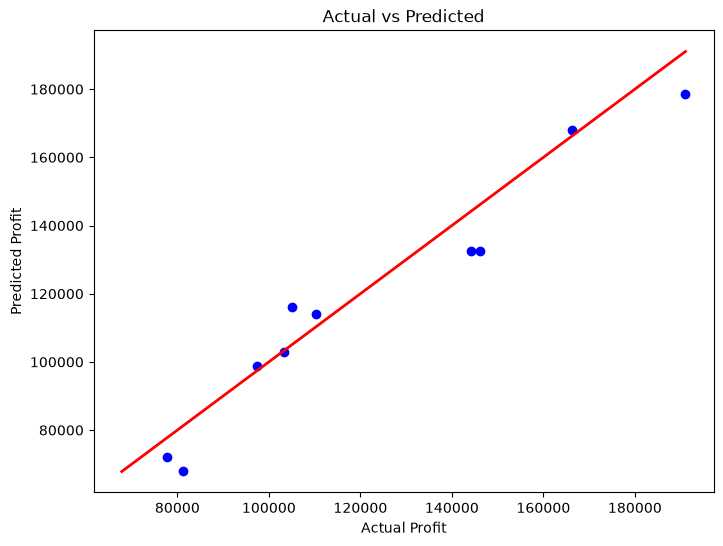

In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(y_test, y_pred, color='blue')

# Perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         color='red',
         linewidth=2)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted")
plt.show()